# Wine Machine Learning Project: 

Author: Rosie Navarro


Date: August 2026


## Exercise 1: 

### A: Combine the red and white wine datasets (data/winequality-red.csv and data/winequality-white.csv, respectively) and add a column for the kind of wine (red or white).


In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import sklearn

from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import fowlkes_mallows_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import roc_curve, roc_auc_score

First step is to import the datasets that are going to be used. Red and white wine quality files. To confirm that the files were uploaded head was used to see the first 15 rows of each dataset. 

In [3]:
red = pd.read_csv("/Users/rosienavarro/Data_Science/Hands-On-Data-Analysis-with-Pandas-2nd-edition-master/ch_09/data/winequality-red.csv")

red.head(15)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.600,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.650,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.580,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.500,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


In [4]:
white = pd.read_csv("/Users/rosienavarro/Data_Science/Hands-On-Data-Analysis-with-Pandas-2nd-edition-master/ch_09/data/winequality-white.csv", sep= ';')

white.head(15)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.70,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.60,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.90,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.50,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.50,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
5,8.1,0.28,0.40,6.90,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
6,6.2,0.32,0.16,7.00,0.045,30.0,136.0,0.9949,3.18,0.47,9.6,6
7,7.0,0.27,0.36,20.70,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
8,6.3,0.30,0.34,1.60,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
9,8.1,0.22,0.43,1.50,0.044,28.0,129.0,0.9938,3.22,0.45,11.0,6


Just by first glance, there are differences in the way that the data is formatted. Although they look different, they have the same 12 variables: fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, density, pH, sulphates, alcohol, and quality. 

Since both files are in a different format, they need to be converted so there is a consistent format, specically the white wine file. This can be done when the file is loaded, at the end sep = ';' is used to identify what is separating each value. 


The next step is to create a column that states the kind of wine, then combine both of the datasets together. 

In [5]:
red["kind"] = 'red'
white["kind"] = 'white'

wine = pd.concat([red, white], ignore_index = True)

wine.head(15)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,kind
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
5,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,red
6,7.9,0.600,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5,red
7,7.3,0.650,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7,red
8,7.8,0.580,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7,red
9,7.5,0.500,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5,red


wine.head(15) helps us confirm that the file was loaded and combined correctly. We can also see that the kind column as successfully added to the table. 

## C: Build and fit a pipeline that scales the data and then uses k-means clustering to make two clusters. Be sure not to use the quality column.

Before this can be done, there are a couple of things that need to be checked, the types of data being used, if there are any missing value in the dataset, and the summary of the data. 

In [6]:
wine.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
kind                    0
dtype: int64

In [7]:
wine.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  kind                  6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 660.0 KB


There are no missing values in the dataset, all results showed up as 0. Additionally, most of the values are floats, expcept for quality(integer) and kind (string). This is important to remember because they are not going to be used for k-means, they will be excluded. info() can also be used to see if there are any missing values, there are 6496 entries all of which are found in all the variables. 



Below we can see the summary and the distribution of the data, with the visualization it is easier to see. 

In [8]:
wine.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


<function matplotlib.pyplot.show(close=None, block=None)>

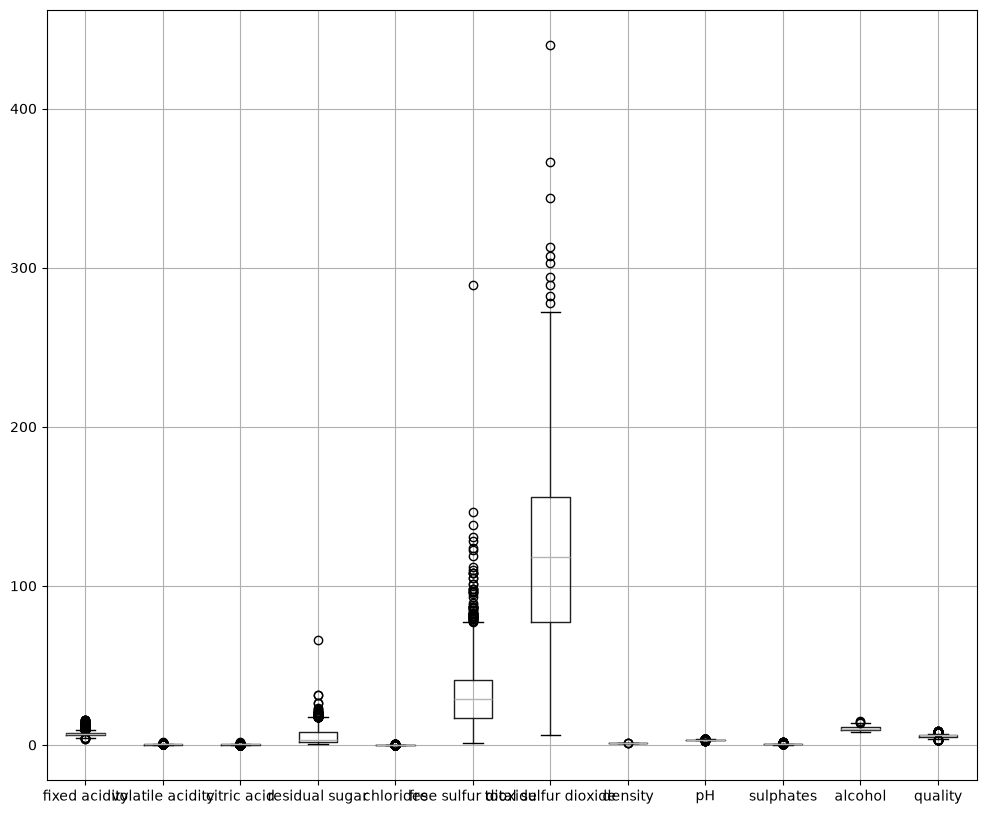

In [9]:
wine.boxplot(figsize=(12, 10))
plt.show

One thing that is immediately seen is that each variable has their own scale. Some of them have really big ranges (for example total sulfur dioxide), while other variables have extremely small ranges (citric acid). The next step is to make sure that the data is in a similar scale in order to do k-means, and to exclude variables that are not needed (kind and quality). 

The following is the actual pipeline.

In [10]:
y = wine['kind']
x_wine = wine.drop(columns=['quality', 'kind'])

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    x_wine, y, test_size=0.25, random_state=0, stratify=y)

wine_kmeans = Pipeline([
    ('scale', StandardScaler()), 
    ('kmeans', KMeans(n_clusters=2, random_state=0, n_init=10))])


wine_kmeans.fit(x_wine)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scale', ...), ('kmeans', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['fixed acidity','volatile acidity','citric acid',...,'pH','sulphates', 'alcohol']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [20]:
clf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf.fit(X_train, y_train)


y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:,1]

Standard Scaler makes it so that the mean of each variable/feature has a mean of 0 and a standard deviation of 1. 

kMeans then uses the scaled data to form the groups. n-clusters is the number of clusters that are being created, this is not the final, there could be some adjustments that need to made in the future. random_state is the stating positions for the centroids. n_init is the number of times that the process is done, in this case it is done 10 times. 


# D: Use the Fowlkes-Mallows Index (the fowlkes_mallows_score() function is in sklearn.metrics) to evaluate how well k-means is able to make the distinction between red and white wine.

FMI tells us how similar clusters are. For this assigment the idea is that there will be two clusters. If the clusters work, they should be grouped into red and white wine. If the index ranges from 0 to 1. If the value is closer to 1, this means that the clustering is similar to the reference clustering. This is an unsupervised method. 

In [21]:
test_cluster = wine_kmeans.predict(X_test)
y_test_en = np.where(y_test == 'red', 0, 1)

fmi = fowlkes_mallows_score(y_test_en, test_cluster)
print(f'Index = {fmi: .4f}')

Index =  0.9854


The Index is very close to 1 (0.9854). This produces a models that has a high agreement with the reference clusters. 

In [22]:
comparison = pd.DataFrame({'true_kind': y_test.values, 'cluster': test_cluster})

pd.crosstab(comparison['true_kind'], comparison['cluster'])

cluster,0,1
true_kind,,
red,2,398
white,1212,13


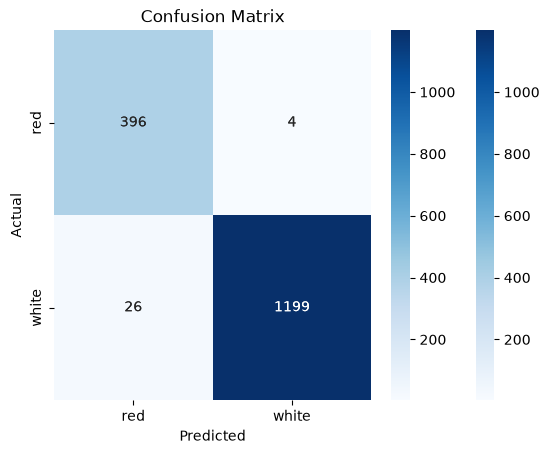

In [24]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['red', 'white'], yticklabels=['red', 'white'])

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The crosstab shows us where the FMI value is coming from. The following shows us the two clusters 1 and 0 and the variables that are (hopefully) being separated. This hows that the majority of red are in 1 and the majority of white are in 0. There are some exceptions, but for the most part the wines are grouped in their own cluster. 
The confusion matrix is another way to visually see the crosstab results. In this case the model was able to differentiate the difference between red and white wine. Out of all of all of the wine, it got 30 wrong. 


# E: Find the center of each cluster.

A centroid is the average position a point can have in a cluster. Since there are 11 variables, the type of wine needs to have a similar value. In simplier terms, it is basically showing us the chemical properties that would be found in red and white wine. Since there are two types of wines, there are two clusters. 

For example the results show us that a red wine migh have higher citric acid and residual sugar, but lower pH and sulphates. 

In [25]:
center = pd.DataFrame(
    wine_kmeans.named_steps['kmeans'].cluster_centers_,
    columns=X_train.columns, 
    index=['cluster 0', 'cluster 1'])

center.T

,cluster 0,cluster 1
fixed acidity,-0.280362,0.829641
volatile acidity,-0.395250,1.169613
citric acid,0.114408,-0.338552
residual sugar,0.199754,-0.591107
chlorides,-0.311148,0.920741
free sulfur dioxide,0.281217,-0.832170
total sulfur dioxide,0.401805,-1.189008
density,-0.230480,0.682029
pH,-0.192053,0.568318
sulphates,-0.284963,0.843254


In [44]:
scaled_data = wine_kmeans.named_steps['scale'].transform(x_wine)

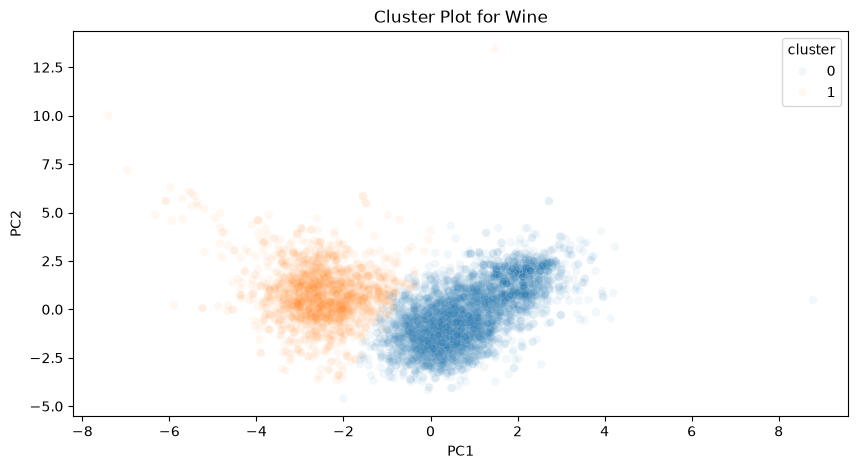

In [45]:
pca = PCA(n_components=2, random_state=0)
pca_result = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
pca_df['cluster'] = wine_kmeans.named_steps['kmeans'].labels_
pca_df['true_kind'] = wine['kind'].values



plt.figure(figsize=(10,5))
plt.title("Cluster Plot for Wine")
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='cluster', palette='tab10', alpha=.06)
plt.show()

The PCA plot shows use where the clusters are located. In this case, there are two distinct clusters. The blue clusters (0) is the red wine, the orange cluster (1) is the white wine. In the middle, the clusters are very close together, in some areas it looks like it is mixed, but there is a clear distiction between the two groups. 

In [46]:
profile = x_wine.copy()
profile['cluster'] = wine_kmeans.named_steps['kmeans'].labels_

cluster_profile = profile.groupby('cluster').mean()
cluster_profile

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
cluster,,,,,,,,,,,
0,6.851864,0.274598,0.335257,6.393554,0.045134,35.516371,138.453563,0.994006,3.187624,0.488867,10.521958
1,8.290798,0.532212,0.269439,2.631079,0.088288,15.755941,48.544790,0.996742,3.309872,0.656740,10.402559


## Classification Forest Model:
This is a collection of decision trees, each one is trained on different features and data. Each tree will vote for the red or white wine. The results are then averaged. The Fowlkes-Mallows score was already high so the results are also expected to be higher here. This is supervised training

In [60]:
X_rf = wine.drop(columns=['quality', 'kind'])
y_rf = wine["kind"].map({'red': 0, 'white': 1})

X_train_wine, X_test_wine, y_train_wine, y_test_wine = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=42, stratify=y_rf)

rf_wine = RandomForestClassifier(n_estimators=200, random_state=42, class_weight = 'balanced')
rf_wine.fit(X_train_wine, y_train_wine)

y_pred_wine = rf_wine.predict(X_test_wine)
y_prob_wine= rf_wine.predict_proba(X_test_wine)[:,1]

In [61]:
print(classification_report(y_test_wine, y_pred_wine))
print(roc_auc_score(y_test_wine, y_prob_wine))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       320
           1       1.00      1.00      1.00       980

    accuracy                           1.00      1300
   macro avg       0.99      0.99      0.99      1300
weighted avg       1.00      1.00      1.00      1300

0.999205994897959


This shows  precision, recall, and f1 scores. Precision was .99 which means that the model predicted 99% of the time.

The AUC score was .99. The model had a 99% chance of making the correct prediction.

The ROC curve for this model should be .99. Rather than being a straight line it is curved closer to the top left corner. This is showing the the model's predictions were almost all correct. 

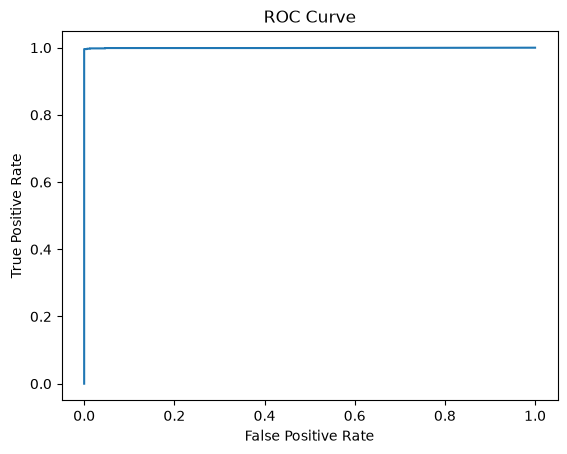

In [62]:
fpr, tpr, _ = roc_curve(y_test_wine, y_prob_wine)
auc = roc_auc_score(y_test_wine, y_prob_wine)
    
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()